In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#create customer master table
customers = {

    "customer_id": [1,2,3,4,5],

    "customer_name": [
        "John",
        "Mary",
        "David",
        "Sarah",
        "Mike"
    ],

    "branch": [
        "Nairobi",
        "Mombasa",
        "Nairobi",
        "Kisumu",
        "Nakuru"
    ],

    "customer_age": [
        25,
        34,
        29,
        42,
        31
    ]
}

customers_df = pd.DataFrame(customers)

customers_df

,customer_id,customer_name,branch,customer_age
0,1,John,Nairobi,25
1,2,Mary,Mombasa,34
2,3,David,Nairobi,29
3,4,Sarah,Kisumu,42
4,5,Mike,Nakuru,31


In [3]:
# create transactions table
transactions = {

    "transaction_id": [
        1001,1002,1003,1004,1005
    ],

    "customer_id": [
        1,2,1,3,5
    ],

    "transaction_amount": [
        45000,
        120000,
        67000,
        98000,
        52000
    ]
}

transactions_df = pd.DataFrame(transactions)

transactions_df

,transaction_id,customer_id,transaction_amount
0,1001,1,45000
1,1002,2,120000
2,1003,1,67000
3,1004,3,98000
4,1005,5,52000


# Now let's understand something
customer_id exists in both tables
# Primary Key - uniquely identifies a row
# Foreign Key - references another table's primary key

In [4]:
#Let's merge the two tables to get a complete view of the customers and their transactions
# Inner Join: returns only the rows where there is a match in both tables
merged_df = pd.merge(

    customers_df,

    transactions_df,

    on="customer_id",

    how="inner"
)

merged_df

#here is the sql equivalent
# SELECT *
# FROM customers
# INNER JOIN transactions
# ON customers.customer_id = transactions.customer_id;

#Note Sarah disappears because she has no transactions. 
# For her to be included, we would need to do a left join instead of an inner join.

,customer_id,customer_name,branch,customer_age,transaction_id,transaction_amount
0,1,John,Nairobi,25,1001,45000
1,1,John,Nairobi,25,1003,67000
2,2,Mary,Mombasa,34,1002,120000
3,5,Mike,Nakuru,31,1005,52000
4,3,David,Nairobi,29,1004,98000


In [5]:
#let's now do a left join to include all customers, even those without transactions
#Left Join - Keeps all records from the left table (customers) and the matched records from the right table (transactions).
# If there is no match, the result will contain NULL values for the right table's columns.
left_join_df = pd.merge(

    customers_df,

    transactions_df,

    on="customer_id",

    how="left"
)

left_join_df

,customer_id,customer_name,branch,customer_age,transaction_id,transaction_amount
0,1,John,Nairobi,25,1001.0,45000.0
1,1,John,Nairobi,25,1003.0,67000.0
2,2,Mary,Mombasa,34,1002.0,120000.0
3,3,David,Nairobi,29,1004.0,98000.0
4,4,Sarah,Kisumu,42,NaN,NaN
5,5,Mike,Nakuru,31,1005.0,52000.0


In [6]:
#Now let's do a right join to include all transactions, even those without matching customers
#Right Join - Keeps all records from the right table (transactions) and the matched records from the left table (customers).
# If there is no match, the result will contain NULL values for the left table's columns.
right_join_df = pd.merge(

    customers_df,

    transactions_df,

    on="customer_id",

    how="right"
)
right_join_df


,customer_id,customer_name,branch,customer_age,transaction_id,transaction_amount
0,1,John,Nairobi,25,1001,45000
1,2,Mary,Mombasa,34,1002,120000
2,1,John,Nairobi,25,1003,67000
3,3,David,Nairobi,29,1004,98000
4,5,Mike,Nakuru,31,1005,52000


In [7]:
#Outer Join - Combines the results of both left and right joins. 
#It returns all records from both tables, with NULL values in place where the join condition is not met.
#It keeps even unmatched records from both tables.
outer_join_df = pd.merge(

    customers_df,

    transactions_df,

    on="customer_id",

    how="outer"
)
outer_join_df


,customer_id,customer_name,branch,customer_age,transaction_id,transaction_amount
0,1,John,Nairobi,25,1001.0,45000.0
1,1,John,Nairobi,25,1003.0,67000.0
2,2,Mary,Mombasa,34,1002.0,120000.0
3,3,David,Nairobi,29,1004.0,98000.0
4,4,Sarah,Kisumu,42,NaN,NaN
5,5,Mike,Nakuru,31,1005.0,52000.0


In [8]:
#Concatenation - This is a method of combining two DataFrames by stacking them on top of each other (row-wise) or side by side (column-wise).
# Difference between merge and concat is that merge is based on a key column(s) while concat is based on the index or simply stacking DataFrames together.
# Merge - Stacks tables horizontally using keys.
# Concatenation - Stacks tables vertically or horizontally without using keys.
#Let's concatenate the customers and transactions tables vertically (row-wise)
new_transactions = {

    "transaction_id": [1006,1007],

    "customer_id": [2,4],

    "transaction_amount": [
        150000,
        76000
    ]
}

new_transactions_df = pd.DataFrame(
    new_transactions
)
new_transactions_df

,transaction_id,customer_id,transaction_amount
0,1006,2,150000
1,1007,4,76000


# Concat is heavily used for:

pipeline ingestion,
monthly appends,
log accumulation,
streaming batches,
warehousing.

In [9]:
# Now let's concatenate the original transactions_df with the new_transactions_df
all_transactions = pd.concat([

    transactions_df,

    new_transactions_df

])

all_transactions

,transaction_id,customer_id,transaction_amount
0,1001,1,45000
1,1002,2,120000
2,1003,1,67000
3,1004,3,98000
4,1005,5,52000
0,1006,2,150000
1,1007,4,76000


In [10]:
#Lambda functions - These are anonymous functions that can be defined in a single line. 
# They are often used for simple operations that can be expressed in a concise way.
#They are very useful for:
# Transformations - Applying a function to each element in a DataFrame or Series.
# Feature Engineering - Creating new features based on existing ones.
# Lightweight business logic - Performing simple calculations or operations without the need to define a full function.

merged_df["transaction_fee"] = merged_df[
    "transaction_amount"
].apply(

    lambda x: x * 0.02
)

merged_df

#Explain the above code - We are creating a new column called "transaction_fee" in the merged_df DataFrame.
# We are using the apply method to apply a lambda function to each value in the "transaction_amount" column.
# The lambda function takes each value x from the "transaction_amount" column and multiplies it by 0.02 to calculate the transaction fee, which is 2% of the transaction amount.

,customer_id,customer_name,branch,customer_age,transaction_id,transaction_amount,transaction_fee
0,1,John,Nairobi,25,1001,45000,900.0
1,1,John,Nairobi,25,1003,67000,1340.0
2,2,Mary,Mombasa,34,1002,120000,2400.0
3,5,Mike,Nakuru,31,1005,52000,1040.0
4,3,David,Nairobi,29,1004,98000,1960.0


In [11]:
# Now lets segment customers
merged_df["customer_segment"] = np.where(

    merged_df["transaction_amount"] >= 100000,

    "Premium",

    "Regular"
)

merged_df

,customer_id,customer_name,branch,customer_age,transaction_id,transaction_amount,transaction_fee,customer_segment
0,1,John,Nairobi,25,1001,45000,900.0,Regular
1,1,John,Nairobi,25,1003,67000,1340.0,Regular
2,2,Mary,Mombasa,34,1002,120000,2400.0,Premium
3,5,Mike,Nakuru,31,1005,52000,1040.0,Regular
4,3,David,Nairobi,29,1004,98000,1960.0,Regular


In [12]:
# Correlation - This is a statistical measure that describes the strength and direction of a relationship between two variables.
# it's very important in:
# Machine Learning - Correlation helps in feature selection and understanding the relationships between features and the target variable.
# Feature selection - Correlation can help identify which features are most relevant to the target variable, allowing us to select the most important features for our model.
# Predictive analytics - Correlation can help identify which variables are most strongly associated with the outcome of interest, allowing us to make more accurate predictions.

merged_df.corr(
    numeric_only=True
)
merged_df.corr(
    numeric_only=True
).style.background_gradient(
    cmap="coolwarm"
)

,customer_id,customer_age,transaction_id,transaction_amount,transaction_fee
customer_id,1.000000,0.551825,0.850420,-0.050790,-0.050790
customer_age,0.551825,1.000000,0.283887,0.670917,0.670917
transaction_id,0.850420,0.283887,1.000000,-0.039815,-0.039815
transaction_amount,-0.050790,0.670917,-0.039815,1.000000,1.000000
transaction_fee,-0.050790,0.670917,-0.039815,1.000000,1.000000


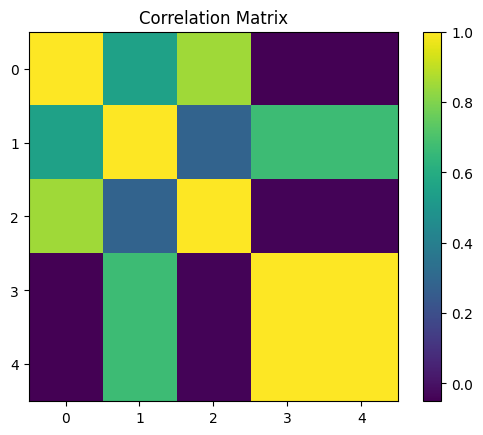

In [13]:
#Exploratory Data Analysis (EDA) - This is the process of analyzing and summarizing a dataset to understand its main characteristics, often using visual methods.
correlation = merged_df.corr(
    numeric_only=True
)

plt.imshow(correlation)

plt.colorbar()

plt.title(
    "Correlation Matrix"
)

plt.show()

In [14]:
merged_df


,customer_id,customer_name,branch,customer_age,transaction_id,transaction_amount,transaction_fee,customer_segment
0,1,John,Nairobi,25,1001,45000,900.0,Regular
1,1,John,Nairobi,25,1003,67000,1340.0,Regular
2,2,Mary,Mombasa,34,1002,120000,2400.0,Premium
3,5,Mike,Nakuru,31,1005,52000,1040.0,Regular
4,3,David,Nairobi,29,1004,98000,1960.0,Regular


In [15]:
#Let's now combine everything
branch_summary = merged_df.groupby(
    "branch"
).agg({

    "transaction_amount": [
        "sum",
        "mean",
        "count"
    ],

    "customer_age": "mean"

})

branch_summary

transaction_amount                 customer_age
                       sum      mean count         mean
branch                                                 
Mombasa             120000  120000.0     1    34.000000
Nairobi             210000   70000.0     3    26.333333
Nakuru               52000   52000.0     1    31.000000

In [16]:
branch_summary.columns = [

    "total_transactions",
    "average_transaction",
    "transaction_count",
    "average_customer_age"

]

branch_summary

,total_transactions,average_transaction,transaction_count,average_customer_age
branch,,,,
Mombasa,120000,120000.0,1,34.000000
Nairobi,210000,70000.0,3,26.333333
Nakuru,52000,52000.0,1,31.000000


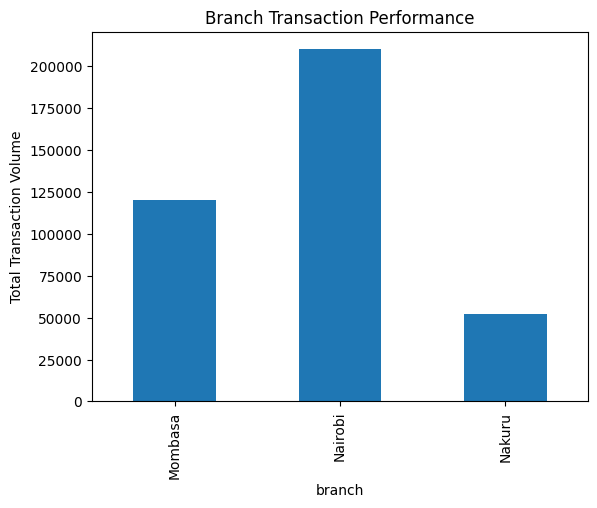

In [17]:

#visualize branch performance
branch_summary["total_transactions"].plot(
    kind="bar"
)

plt.title(
    "Branch Transaction Performance"
)

plt.ylabel(
    "Total Transaction Volume"
)

plt.show()

In [18]:
# export the branch summary to a csv file
merged_df.to_csv(
    "../datasets/day_3_merged_data.csv",
    index=False
)